In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import MNIST
from torchvision import transforms       # used to converting images to numbers
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt



In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("using device", device)

# transform to tensor
Transform = transforms.ToTensor()

train_data = MNIST(root="data",
                   train=True,
                   download=True,
                   transform=Transform)

using device cpu


In [ ]:
test_data = MNIST(root="data",
                train=False,
                download=True,
                transform=Transform)

In [ ]:
train_loader=DataLoader(train_data,
                        batch_size=64,
                        shuffle=True)

test_loader=DataLoader(test_data,
                       batch_size=64,
                       shuffle=False)

Epoch 1/5 | Loss: 0.3439
Epoch 2/5 | Loss: 0.1412
Epoch 3/5 | Loss: 0.0976
Epoch 4/5 | Loss: 0.0711
Epoch 5/5 | Loss: 0.0560
Total Accuracy: 97.47%


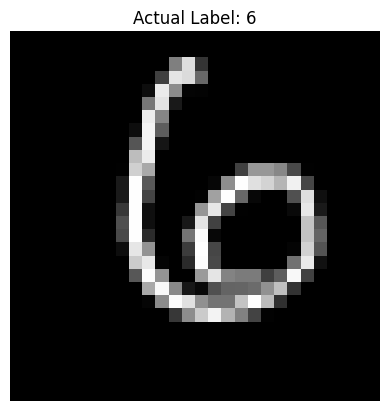

Actual Label: 6
Model Prediction: 6


In [ ]:
class Digitmodel(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential( #by nn.Sequential allows stack layer
        nn.Linear(28*28, 128),# input layer (flattened 28x28 image → 784 features)
       # nn.Linear(in_features, out_features)
        nn.ReLU(),            # nn.ReLU is an Activation fn without this ...
        nn.Linear(128, 64),   # hidden layer
        nn.ReLU(),
        nn.Linear(64, 10)     # output layer (10 classes: digits 0–9)
    )

  def forward(self, x):
    return self.net(x)

model = Digitmodel().to(device) #Moves model to GPU/CPU (device).
loss_fun = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)#adaptive learning rate


#tranning loop
epochs = 5
for epoch in range(epochs):
  model.train()
  total_loss = 0
  for images, labels in train_loader:
    images = images.view(images.size(0), -1).to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = loss_fun(outputs, labels)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()

  print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")

model.eval()
correct = 0
total = 0

with torch.no_grad():
  for images, labels in test_loader:
    images = images.view(images.size(0), -1).to(device)
    labels = labels.to(device)
    outputs = model(images)
    predictions = outputs.argmax(dim=1) # pick class with highest score
    correct += (predictions == labels).sum().item()
    total += labels.size(0)

accuracy = 100 * correct / total
print(f"Total Accuracy: {accuracy:.2f}%")

torch.save(model.state_dict(), "mnist_model.pth")

# Visualization
index = 100
image, true_label = test_data[index]
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Actual Label: {true_label}")
plt.axis("off")
plt.show()

image_flat = image.view(1, -1).to(device)
with torch.no_grad():
  output = model(image_flat)
  predicted_label = output.argmax(dim=1).item()

print("Actual Label:", true_label)
print("Model Prediction:", predicted_label)

### Locate and Download Saved Model

In [ ]:
import os
from google.colab import files

# List files to confirm existence
print("Files in current directory:", os.listdir('.'))

# Trigger a download of the model file
if os.path.exists('mnist_model.pth'):
    files.download('mnist_model.pth')
else:
    print('File not found. Please ensure the training cell finished successfully.')

Files in current directory: ['.config', 'mnist_model.pth', 'data', 'sample_data']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# using CNN

'''Train set → uses augmentation (rotation + flip + normalization).

Test set → only normalized (no augmentation, so evaluation is fair).

This way, your CNN learns to handle variations but is tested on clean digits.'''

Epoch 1/5 | Loss: 0.4312
Epoch 2/5 | Loss: 0.2339
Epoch 3/5 | Loss: 0.2001
Epoch 4/5 | Loss: 0.1756
Epoch 5/5 | Loss: 0.1597
Total Accuracy: 98.39%


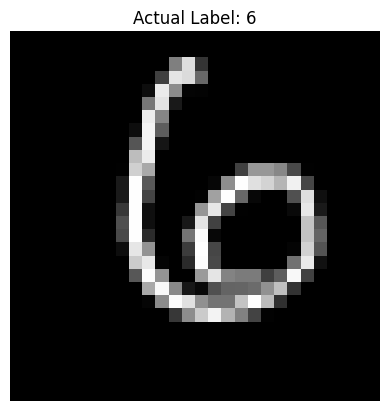

Actual Label: 6
Model Prediction: 6


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset
# Training transform with augmentation
train_transform = transforms.Compose([
    transforms.RandomRotation(10),          # rotate digits up to ±10 degrees
    transforms.RandomHorizontalFlip(),      # randomly flip digits horizontally
    transforms.ToTensor(),                  # convert to tensor
    transforms.Normalize((0.5,), (0.5,))    # normalize pixel values
])

# Test transform (no augmentation, only normalization)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=train_transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=test_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# CNN Model with BatchNorm + Dropout
class CNNmodel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3),        # Conv layer 1
            nn.BatchNorm2d(32),         # BatchNorm after conv
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, 3),       # Conv layer 2
            nn.BatchNorm2d(64),         # BatchNorm after conv
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Flatten(),
            nn.Linear(64*5*5, 128),
            nn.ReLU(),
            nn.Dropout(0.5),            # Dropout after dense layer
            nn.Linear(128, 10)          # Output layer (10 digits)
        )

    def forward(self, x):
        return self.net(x)


model = CNNmodel().to(device)

# Loss & Optimizer
loss_fun = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
epochs = 5
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fun(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")

# Evaluation
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
print(f"Total Accuracy: {accuracy:.2f}%")

# Save model
torch.save(model.state_dict(), "cnn_mnist_model.pth")

# Visualization
index = 100
image, true_label = test_dataset[index]
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Actual Label: {true_label}")
plt.axis("off")
plt.show()

image = image.unsqueeze(0).to(device)  # add batch dimension
with torch.no_grad():
    output = model(image)
    predicted_label = output.argmax(dim=1).item()

print("Actual Label:", true_label)
print("Model Prediction:", predicted_label)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')